In [1]:

import xarray as xr
import pandas as pd
import numpy as np


ds_sat = xr.open_dataset('LGMR_data/ds_sat_flipped.nc')
ds_sat.info()

df_pre = pd.read_csv(r"D:\VScode\Inso_LGMR\inso_data\pre.csv")

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


# Prepare DataFrame
df = pd.DataFrame({
    'Time': ds_sat['age'].values,
    'X': ds_sat['sat'].isel(lat=80).isel(lon=0).values,
    'Y': df_pre['pre'].values
    
})

xarray.Dataset {
dimensions:
	lat = 96 ;
	lon = 144 ;
	age = 120 ;

variables:
	float32 lat(lat) ;
		lat:FillValue = 9.969209968386869e+36 ;
		lat:long_name = vector latitudes ;
		lat:units = degrees_north ;
	float32 lon(lon) ;
		lon:FillValue = 9.969209968386869e+36 ;
		lon:long_name = vector of longitudes ;
		lon:units = degrees_east ;
	float32 age(age) ;
	float32 sat(age, lat, lon) ;
		sat:FillValue = 9.969209968386869e+36 ;
		sat:long_name = ENSEMBLE MEAN (n = 500) mean annual temperature at reference height ;
		sat:units = degrees Celsius ;
	float32 sat_std(age, lat, lon) ;
		sat_std:FillValue = 9.969209968386869e+36 ;
		sat_std:long_name = ENSEMBLE STANDARD DEVIATION (n = 500) mean annual temperature at reference height ;
		sat_std:units = degrees Celsius ;

// global attributes:
}

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# EMD from the PyEMD library
from PyEMD import EMD

# Hilbert transform from scipy
from scipy.signal import hilbert

def hilbert_huang_20k(ds_sat, lat_idx=80, lon_idx=0):
    """
    1) Extract the SAT time series from ds_sat at (lat_idx, lon_idx).
    2) Perform EMD to get the Intrinsic Mode Functions (IMFs).
    3) Identify the IMF with a ~20,000-year period.
    4) Use the Hilbert transform to compute the time-varying amplitude of that IMF.
    5) Plot the original signal, all IMFs, and the ~20k IMF + amplitude.
    """

    # --------------------------------------------------
    # 1) Extract data
    # --------------------------------------------------
    # ds_sat['age'] is the time array, step = 200 yrs
    # ds_sat['sat'] is the 3D array (age, lat, lon)
    time = ds_sat["age"].values           # shape (N_time,)
    sat_data = ds_sat["sat"].isel(lat=lat_idx, lon=lon_idx).values  # shape (N_time,)

    # The time step is typically 200 yrs
    dt = np.mean(np.diff(time))  # should be ~200

    # --------------------------------------------------
    # 2) Perform Empirical Mode Decomposition (EMD)
    # --------------------------------------------------
    emd = EMD()
    # EMD can take either just the signal or (signal, time). For basic usage:
    imfs = emd.emd(sat_data)  # shape => (n_imfs, N_time)
    n_imfs = imfs.shape[0]

    # --------------------------------------------------
    # Plot the original data
    # --------------------------------------------------
    plt.figure(figsize=(10, 3))
    plt.plot(time, sat_data, label="Original SAT data")
    plt.gca().invert_xaxis()  # If you want older times on left
    plt.title("SAT Time Series at lat=80, lon=0")
    plt.xlabel("Age (years)")
    plt.ylabel("SAT")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------
    # Plot all IMFs
    # --------------------------------------------------
    fig, axes = plt.subplots(n_imfs, 1, figsize=(10, 2*n_imfs), sharex=True)
    for i in range(n_imfs):
        axes[i].plot(time, imfs[i, :])
        axes[i].invert_xaxis()  # optional
        axes[i].set_ylabel(f"IMF {i+1}")
    axes[-1].set_xlabel("Age (years)")
    axes[0].set_title("All IMFs from EMD")
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------
    # 3) Identify which IMF has a characteristic period ~ 20,000 yrs
    # --------------------------------------------------
    # We'll do this by Hilbert transform of each IMF, computing the "mean period."
    # The instantaneous frequency is:
    #   f(t) = (1 / (2π)) * d(φ(t))/dt,
    # where φ(t) is the unwrapped phase from Hilbert transform.
    # Then "mean_f" is the average over time, so "mean_T" = 1 / mean_f.

    candidate_periods = []
    for i in range(n_imfs):
        # 1) Hilbert transform of IMF i
        analytic_signal = hilbert(imfs[i, :])
        phase = np.unwrap(np.angle(analytic_signal))

        # 2) Instantaneous freq = derivative of phase / (2π*dt)
        inst_freq = np.diff(phase) / (2.0 * np.pi * dt)  # in cycles/year
        mean_f = np.mean(inst_freq)  # average cycles/year
        # If mean_f is near zero, skip
        if np.isclose(mean_f, 0, atol=1e-12):
            mean_T = np.inf
        else:
            mean_T = 1.0 / mean_f  # period in years

        candidate_periods.append(mean_T)

    # Convert to array
    candidate_periods = np.array(candidate_periods)
    # Find which IMF is closest to 20k yrs
    target_period = 20000
    idx_20k = np.argmin(np.abs(candidate_periods - target_period))

    print("IMF index with ~20k period:", idx_20k+1)
    print("Estimated period(s):", candidate_periods)

    # The selected IMF
    imf_20k = imfs[idx_20k, :]

    # --------------------------------------------------
    # 4) Hilbert transform of that IMF => Time-varying amplitude
    # --------------------------------------------------
    analytic_20k = hilbert(imf_20k)
    amplitude_20k = np.abs(analytic_20k)

    # --------------------------------------------------
    # 5) Plot the selected IMF and its amplitude
    # --------------------------------------------------
    fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

    ax[0].plot(time, imf_20k, label="~20k-yr IMF")
    ax[0].invert_xaxis()  # optional
    ax[0].set_ylabel("Value")
    ax[0].legend()

    ax[1].plot(time, amplitude_20k, label="Amplitude", color="crimson")
    ax[1].invert_xaxis()  # optional
    ax[1].set_xlabel("Age (years)")
    ax[1].set_ylabel("Amplitude")
    ax[1].legend()

    ax[0].set_title("Selected IMF (~20,000 yrs) and Its Time-Varying Amplitude")
    plt.tight_layout()
    plt.show()


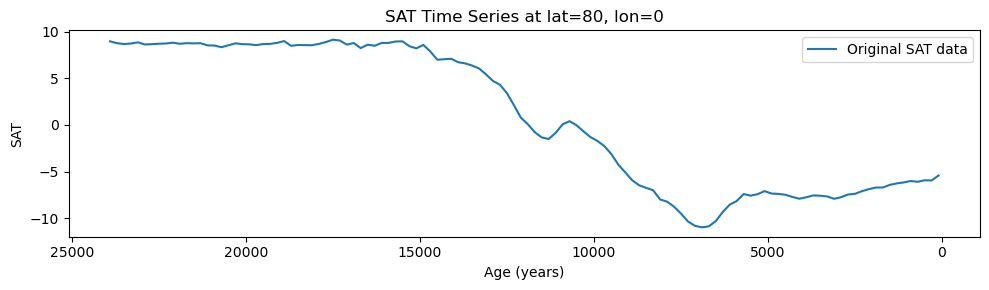

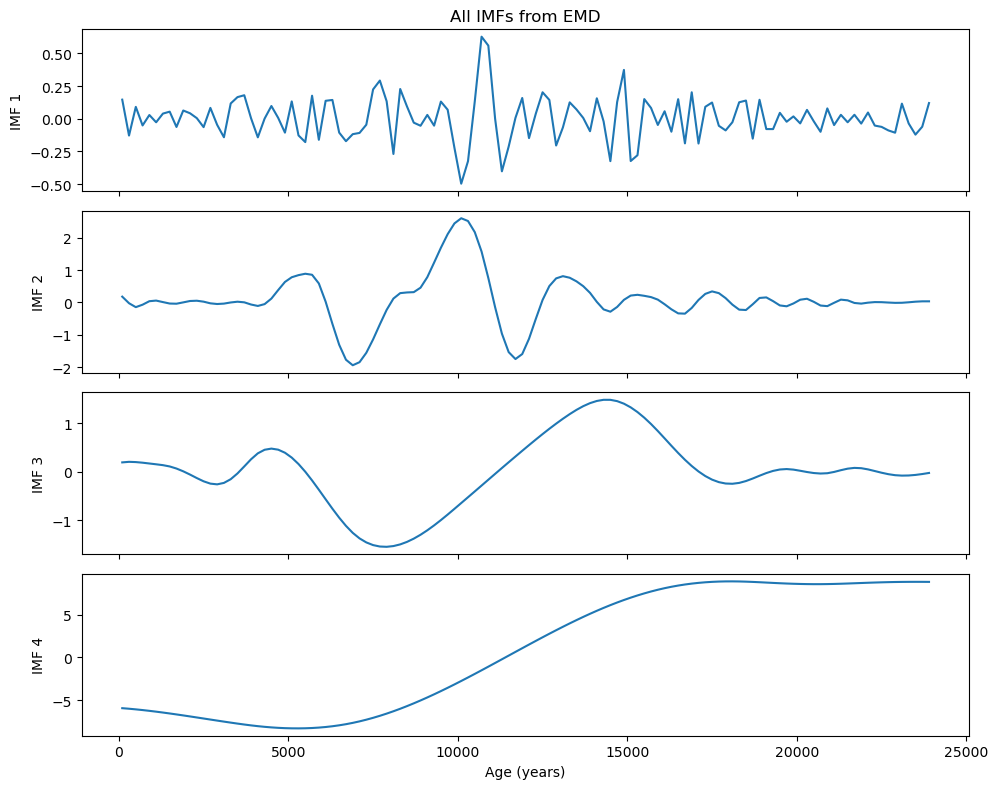

IMF index with ~20k period: 4
Estimated period(s): [  924.66852289  2206.27469751  8642.76030368 26325.15480234]


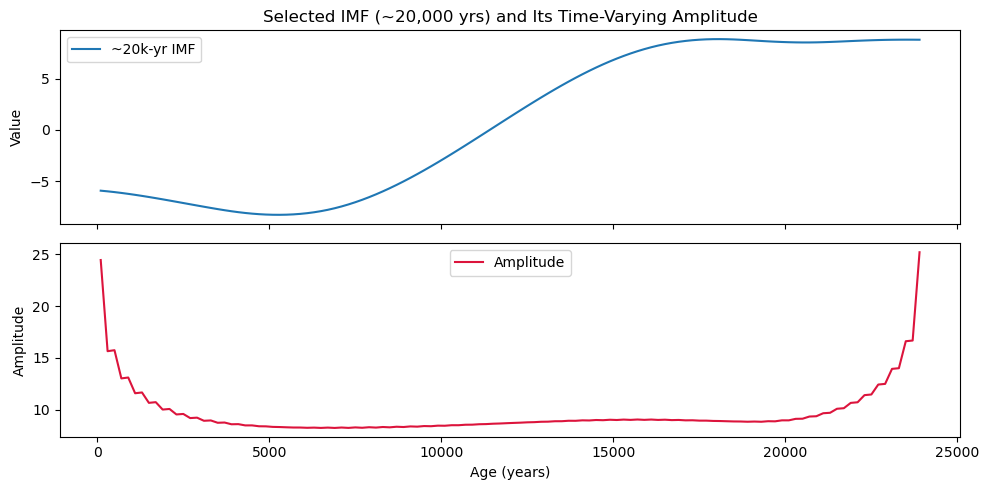

In [4]:
hilbert_huang_20k(ds_sat, lat_idx=80, lon_idx=0)